Downloading...
From: https://storage.yandexcloud.net/quize-backet/azia_arjento.jpg
To: /content/actress.jpg
100%|██████████| 39.5k/39.5k [00:00<00:00, 1.33MB/s]


Найден 1 глаз, дорисовываем второй симметрично
✓ Очки успешно добавлены


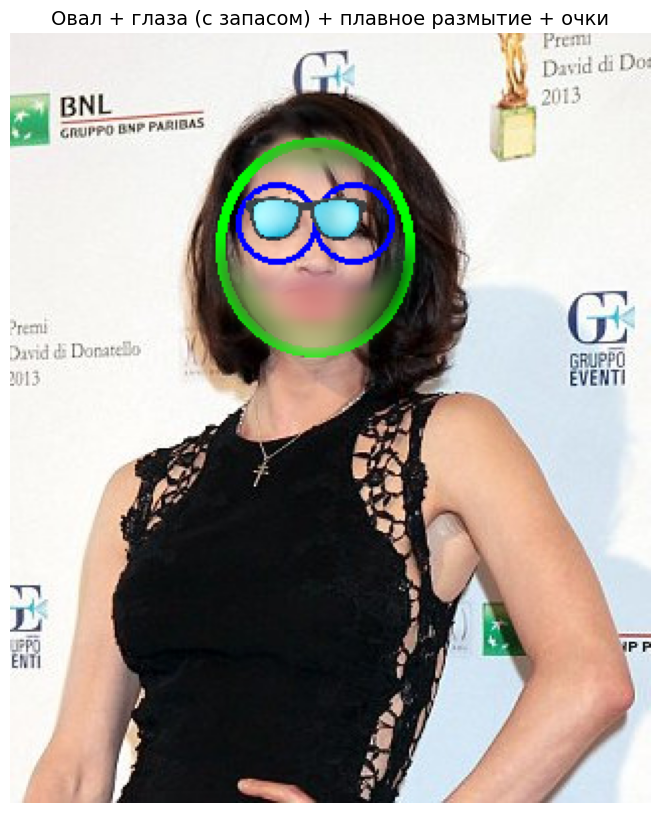

In [2]:
import cv2
import numpy as np
import gdown
from matplotlib import pyplot as plt

# Загружаем фото
image_url = "https://storage.yandexcloud.net/quize-backet/azia_arjento.jpg"
gdown.download(image_url, "actress.jpg", quiet=False)
img = cv2.imread("actress.jpg")
img_copy = img.copy()

# Загружаем каскады
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_alt2.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Распознаём лицо
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))

if len(faces) == 0:
    print("Лицо не найдено")
else:
    (x, y, w, h) = faces[0]

    # Рисуем овал вокруг лица
    center = (x + w // 2, y + h // 2)
    axes = (w // 2, int(h // 1.8))
    cv2.ellipse(img_copy, center, axes, 0, 0, 360, (0, 255, 0), 3)

    # Распознаём глаза внутри лица
    gray_face = gray[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(gray_face, scaleFactor=1.1, minNeighbors=5, minSize=(20, 20))

    eye_centers = []
    eye_radiuses = []

    # Обработка глаз
    if len(eyes) == 2:
        # Идеальный случай, если найдено 2 глаза
        print("Найдено ровно 2 глаза")
        for (ex, ey, ew, eh) in eyes:
            eye_center = (x + ex + ew//2, y + ey + eh//2)
            eye_centers.append(eye_center)
            radius = int(0.4 * (ew + eh))  # увеличен радиус
            eye_radiuses.append(radius)
            cv2.circle(img_copy, eye_center, radius, (255, 0, 0), 2)

    elif len(eyes) == 1:
        # Найден один глаз — дорисовываем второй симметрично
        print("Найден 1 глаз, дорисовываем второй симметрично")
        (ex, ey, ew, eh) = eyes[0]
        eye1_center = (x + ex + ew//2, y + ey + eh//2)
        face_center_x = x + w // 2
        offset = abs(face_center_x - eye1_center[0])
        if eye1_center[0] < face_center_x:
            eye2_center = (face_center_x + offset, eye1_center[1])
        else:
            eye2_center = (face_center_x - offset, eye1_center[1])
        eye_centers = [eye1_center, eye2_center]
        radius = int(0.4 * (ew + eh))
        eye_radiuses = [radius, radius]
        for ec in eye_centers:
            cv2.circle(img_copy, ec, radius, (255, 0, 0), 2)

    elif len(eyes) >= 3:
        # Берём два самых крупных глаза
        print(f"Найдено {len(eyes)} глаз, берём два самых крупных")
        eyes_sorted = sorted(eyes, key=lambda e: e[2] * e[3], reverse=True)
        for (ex, ey, ew, eh) in eyes_sorted[:2]:
            eye_center = (x + ex + ew//2, y + ey + eh//2)
            eye_centers.append(eye_center)
            radius = int(0.4 * (ew + eh))
            eye_radiuses.append(radius)
            cv2.circle(img_copy, eye_center, radius, (255, 0, 0), 2)

    else:
        print("Глаза не найдены")

    # Создаём маску-овал для размытия
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)

    # Вырезаем глаза из маски с увеличенным запасом
    for (cx, cy), r in zip(eye_centers, eye_radiuses):
        cv2.circle(mask, (cx, cy), r + 10, 0, -1)  # +10 вместо +5

    # Плавные границы маски
    mask = cv2.GaussianBlur(mask, (15, 15), 5)

    # Размываем изображение
    blurred = cv2.GaussianBlur(img_copy, (31, 31), 20)

    # Плавное смешивание
    mask_3ch = mask[:, :, np.newaxis] / 255.0
    img_copy = (blurred * mask_3ch + img_copy * (1 - mask_3ch)).astype(np.uint8)

    # Очки
    glasses_url = "https://storage.yandexcloud.net/quize-backet/glasses.png"
    try:
        gdown.download(glasses_url, "glasses.png", quiet=True)
        glasses = cv2.imread("glasses.png", cv2.IMREAD_UNCHANGED)

        if len(eye_centers) >= 2 and glasses is not None:
            eye_centers.sort(key=lambda p: p[0])
            left_eye, right_eye = eye_centers[0], eye_centers[1]

            eye_distance = abs(right_eye[0] - left_eye[0])
            glasses_width = int(eye_distance * 1.6)
            glasses_height = int(glasses_width * glasses.shape[0] / glasses.shape[1])
            glasses_resized = cv2.resize(glasses, (glasses_width, glasses_height))

            glasses_x = left_eye[0] - int(glasses_width * 0.25)
            glasses_y = left_eye[1] - int(glasses_height * 0.6)

            # Проверка границ
            if glasses_y < 0:
                glasses_y = 0
            if glasses_x < 0:
                glasses_x = 0

            for c in range(3):
                if glasses_resized.shape[0] > 0 and glasses_resized.shape[1] > 0:
                    alpha = glasses_resized[:, :, 3] / 255.0
                    roi = img_copy[glasses_y:glasses_y+glasses_height, glasses_x:glasses_x+glasses_width, c]
                    if roi.shape == glasses_resized[:, :, c].shape:
                        img_copy[glasses_y:glasses_y+glasses_height, glasses_x:glasses_x+glasses_width, c] = \
                            glasses_resized[:, :, c] * alpha + roi * (1 - alpha)
            print("✓ Очки успешно добавлены")
        else:
            print("Не удалось добавить очки")
    except Exception as e:
        print(f"Ошибка с очками: {e}")

    # Результат
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Овал + глаза (с запасом) + плавное размытие + очки", fontsize=14)
    plt.show()